In [39]:
import os
import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.stats import pearsonr, kendalltau

from trials.utils import *

In [40]:
ground_truth_path = r'../outputs/dpav4/ground_truth_assessments/mlp__seed=0__window_size=5.npz'
hparam_sweep_dir = r'/home/jgammell/Desktop/mi_leakage_localization/outputs/dpav4/ll_hparam_sweep'

In [41]:
ground_truth_assessments = np.load(ground_truth_path, allow_pickle=True)['assessments'].item()
ground_truth_mutinfs = -np.stack([x['rank'] for x in ground_truth_assessments.values()]).sum(axis=0)

In [42]:
def compare_to_ground_truth_mutinf(x):
    x_reduced = torch.tensor(x).unfold(0, 5, 1).numpy().mean(axis=-1)
    rv = {
        'pearsonr': pearsonr(x_reduced, ground_truth_mutinfs).statistic,
        'kendalltau': kendalltau(x_reduced, ground_truth_mutinfs).statistic
    }
    return rv

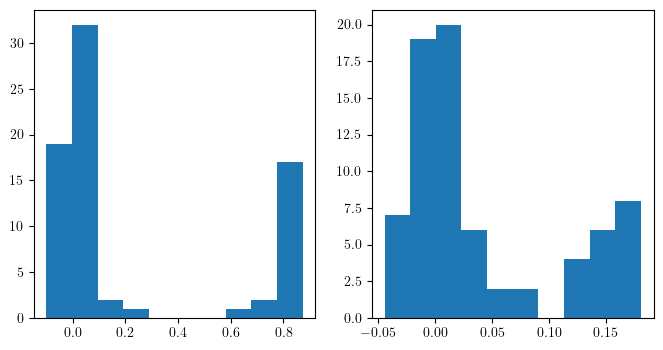

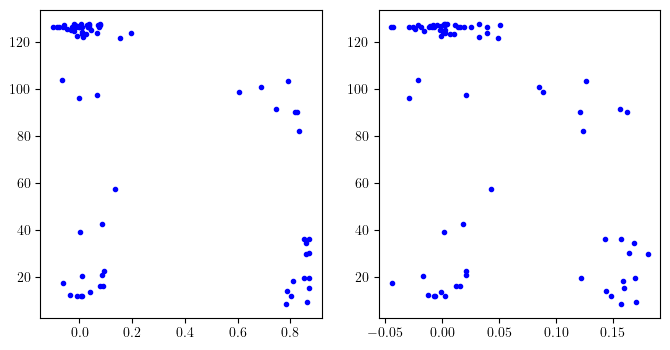

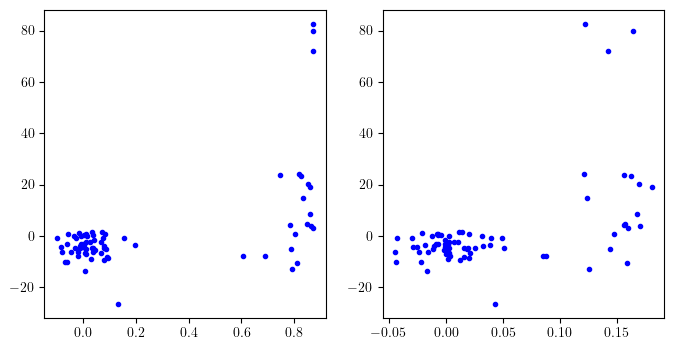

In [44]:
pearsonr_vals = []
kendalltau_vals = []
mean_theta_rank = []
diff_theta_rank = []
for idx in range(100):
    experiment_dir = os.path.join(hparam_sweep_dir, f'trial_{idx}')
    leakage_assessment_path = os.path.join(experiment_dir, 'leakage_assessment.npz')
    try:
        leakage_assessment = np.load(leakage_assessment_path, allow_pickle=True)['leakage_assessment']
        training_curves = get_training_curves(experiment_dir)
        rv = compare_to_ground_truth_mutinf(leakage_assessment)
        pearsonr_vals.append(rv['pearsonr'])
        kendalltau_vals.append(rv['kendalltau'])
        mean_theta_rank.append(np.mean(training_curves['val_theta_rank'][-1]))
        diff_theta_rank.append(training_curves['val_theta_rank'][-1][0] - training_curves['val_theta_rank'][-1][-1])
    except:
        continue
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].hist(pearsonr_vals)
axes[1].hist(kendalltau_vals)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].plot(pearsonr_vals, mean_theta_rank, marker='.', linestyle='none', color='blue')
axes[1].plot(kendalltau_vals, mean_theta_rank, marker='.', linestyle='none', color='blue')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].plot(pearsonr_vals, diff_theta_rank, marker='.', linestyle='none', color='blue')
axes[1].plot(kendalltau_vals, diff_theta_rank, marker='.', linestyle='none', color='blue')